In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
base_path = "/content/drive/MyDrive/DRIVE"

In [3]:
import os
print(os.listdir(base_path))

['.DS_Store', 'training', 'test']


In [4]:
import cv2
import os
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/DRIVE"

img_path = base_path + "/training/images"
mask_path = base_path + "/training/1st_manual"

# pick first image
img_name = sorted(os.listdir(img_path))[0]

img = cv2.imread(os.path.join(img_path, img_name))

print("Image name:", img_name)
print("Shape:", img.shape)

Image name: 21_training.tif
Shape: (584, 565, 3)


(np.float64(-0.5), np.float64(564.5), np.float64(583.5), np.float64(-0.5))

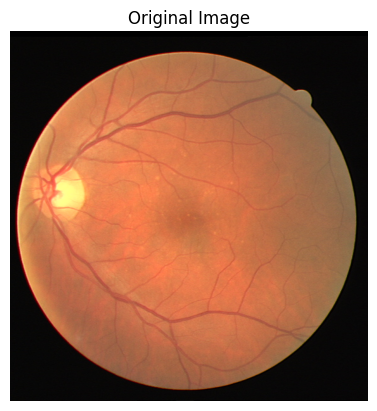

In [5]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

In [7]:
print("Image file:", img_name)

print("\nAvailable masks:")
print(os.listdir(mask_path)[:5])

Image file: 21_training.tif

Available masks:
['31_manual1.gif', '29_manual1.gif', '36_manual1.gif', '38_manual1.gif', '28_manual1.gif']


In [8]:
mask_files = sorted(os.listdir(mask_path))
mask = cv2.imread(os.path.join(mask_path, mask_files[0]), 0)

In [9]:
print(type(mask))
print(mask.shape)

<class 'numpy.ndarray'>
(584, 565)


(np.float64(-0.5), np.float64(564.5), np.float64(583.5), np.float64(-0.5))

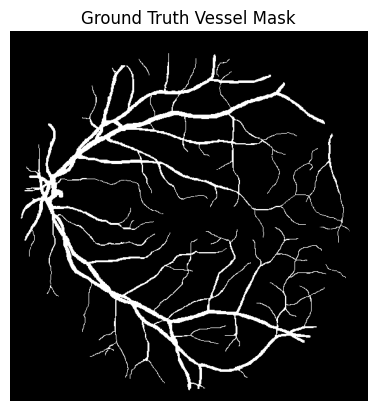

In [10]:
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth Vessel Mask")
plt.axis("off")

In [11]:
import numpy as np

def single_scale_retinex(img, sigma=30):
    img = img.astype(np.float32) + 1.0

    blur = cv2.GaussianBlur(img, (0, 0), sigma)

    retinex = np.log(img) - np.log(blur)

    return retinex

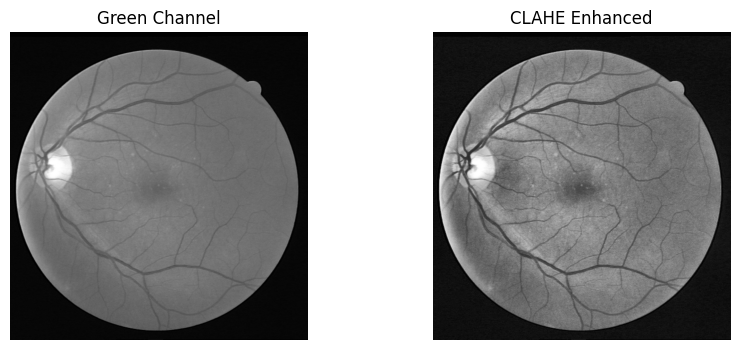

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# paths
base_path = "/content/drive/MyDrive/DRIVE"
img_path = base_path + "/training/images"

# load image
img_name = sorted(os.listdir(img_path))[0]
img = cv2.imread(os.path.join(img_path, img_name))

# green channel
green = img[:, :, 1]

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_img = clahe.apply(green)

# compare
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Green Channel")
plt.imshow(green, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("CLAHE Enhanced")
plt.imshow(clahe_img, cmap='gray')
plt.axis("off")

plt.show()

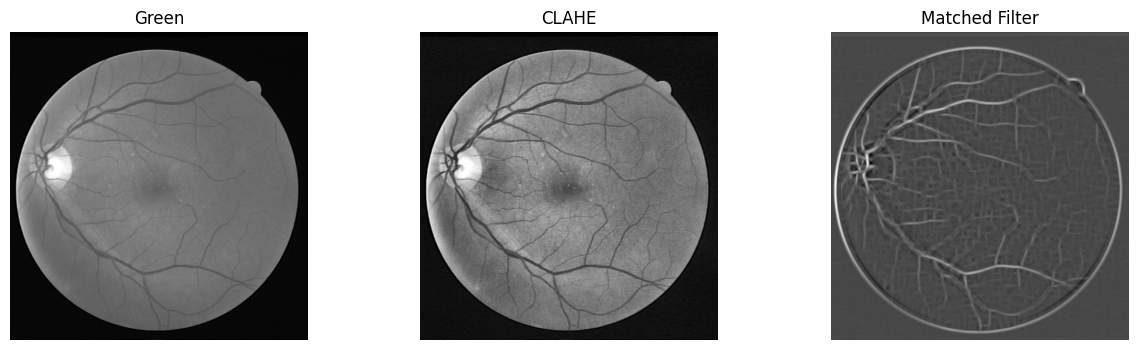

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# paths
base_path = "/content/drive/MyDrive/DRIVE"
img_path = base_path + "/training/images"

# load image
img_name = sorted(os.listdir(img_path))[0]
img = cv2.imread(os.path.join(img_path, img_name))

# green channel
green = img[:, :, 1]

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_img = clahe.apply(green)

# correct matched filter kernel (2D Gaussian line)
def create_matched_filter(size=15, sigma=2):
    kernel = np.zeros((size, size))
    center = size // 2

    for x in range(size):
        for y in range(size):
            kernel[x, y] = -np.exp(-((y - center)**2) / (2 * sigma**2))

    kernel = kernel - np.mean(kernel)
    return kernel

# apply matched filtering
def apply_matched_filter(img):
    responses = []
    kernel = create_matched_filter()

    for angle in range(0, 180, 15):
        M = cv2.getRotationMatrix2D((kernel.shape[1]//2, kernel.shape[0]//2), angle, 1)
        rotated = cv2.warpAffine(kernel, M, (kernel.shape[1], kernel.shape[0]))

        res = cv2.filter2D(img, cv2.CV_32F, rotated)
        responses.append(res)

    response = np.max(responses, axis=0)

    # normalize properly
    response = cv2.normalize(response, None, 0, 255, cv2.NORM_MINMAX)
    return response.astype(np.uint8)

mf_img = apply_matched_filter(clahe_img)

# compare
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Green")
plt.imshow(green, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("CLAHE")
plt.imshow(clahe_img, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Matched Filter")
plt.imshow(mf_img, cmap='gray')
plt.axis("off")

plt.show()

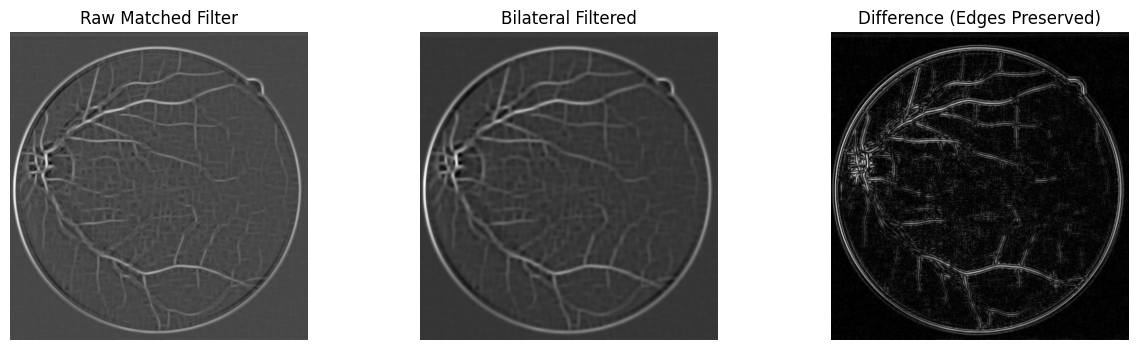

In [19]:
# bilateral filtering (edge-preserving)

clean = cv2.bilateralFilter(mf_img, d=9, sigmaColor=75, sigmaSpace=75)

# compare
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Raw Matched Filter")
plt.imshow(mf_img, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Bilateral Filtered")
plt.imshow(clean, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Difference (Edges Preserved)")
plt.imshow(cv2.absdiff(mf_img, clean), cmap='gray')
plt.axis("off")

plt.show()

In [20]:
def extract_features(img):
    # green channel
    green = img[:, :, 1]

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(green)

    # matched filter
    mf_img = apply_matched_filter(clahe_img)

    # stack features
    features = np.stack([clahe_img, mf_img], axis=-1)

    return features

In [21]:
features = extract_features(img)

print("Feature shape:", features.shape)

Feature shape: (584, 565, 2)


In [22]:
def create_training_data(images, vessel_masks, fov_masks, sample_ratio=0.1):
    X, y = [], []

    for img, vessel, fov in zip(images, vessel_masks, fov_masks):
        # features
        feat = extract_features(img)

        # flatten
        feat = feat.reshape(-1, feat.shape[-1])
        vessel = vessel.flatten()
        fov = fov.flatten()

        # keep only retina pixels
        valid_idx = np.where(fov > 0)[0]

        # sample for speed
        sample_size = int(len(valid_idx) * sample_ratio)
        sampled_idx = np.random.choice(valid_idx, sample_size, replace=False)

        X.append(feat[sampled_idx])
        y.append(vessel[sampled_idx] // 255)

    return np.vstack(X), np.hstack(y)

In [24]:
import os
import cv2

def load_drive_data(base_path, split='training'):
    images = []
    vessel_masks = []
    fov_masks = []

    img_path = os.path.join(base_path, split, 'images')
    fov_path = os.path.join(base_path, split, 'mask')

    if split == 'training':
        gt_path = os.path.join(base_path, split, '1st_manual')

    img_files = sorted(os.listdir(img_path))
    fov_files = sorted(os.listdir(fov_path))

    if split == 'training':
        gt_files = sorted(os.listdir(gt_path))

    for i in range(len(img_files)):
        img = cv2.imread(os.path.join(img_path, img_files[i]))
        fov = cv2.imread(os.path.join(fov_path, fov_files[i]), 0)

        if split == 'training':
            gt = cv2.imread(os.path.join(gt_path, gt_files[i]), 0)
        else:
            gt = None

        images.append(img)
        vessel_masks.append(gt)
        fov_masks.append(fov)

    return images, vessel_masks, fov_masks


# load training data
base_path = "/content/drive/MyDrive/DRIVE"
train_imgs, train_gt, train_fov = load_drive_data(base_path, 'training')

print("Loaded training images:", len(train_imgs))

Loaded training images: 20


In [25]:
X_train, y_train = create_training_data(train_imgs, train_gt, train_fov)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (454091, 2)
y_train shape: (454091,)


In [26]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# define model
model = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),
    n_estimators=50
)

# train
model.fit(X_train, y_train)

print("Model training complete")

Model training complete


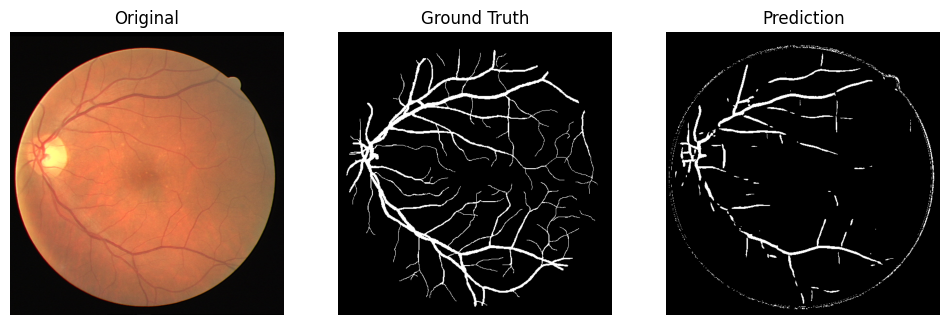

In [27]:
def predict_image(img, model):
    feat = extract_features(img)
    h, w, _ = feat.shape

    feat = feat.reshape(-1, feat.shape[-1])
    pred = model.predict(feat)

    return pred.reshape(h, w)


# test on first training image
test_img = train_imgs[0]
pred = predict_image(test_img, model)

# show result
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(train_gt[0], cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred, cmap='gray')
plt.axis("off")

plt.show()

In [28]:
def extract_features(img):
    # green channel
    green = img[:, :, 1]

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    clahe_img = clahe.apply(green)

    # matched filter
    mf_img = apply_matched_filter(clahe_img)

    # gradient magnitude
    sobelx = cv2.Sobel(clahe_img, cv2.CV_32F, 1, 0, ksize=3)
    sobely = cv2.Sobel(clahe_img, cv2.CV_32F, 0, 1, ksize=3)
    gradient = np.sqrt(sobelx**2 + sobely**2)
    gradient = cv2.normalize(gradient, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # local variance
    blur = cv2.GaussianBlur(clahe_img, (5,5), 0)
    variance = cv2.absdiff(clahe_img, blur)

    # stack features
    features = np.stack([clahe_img, mf_img, gradient, variance], axis=-1)

    return features

In [29]:
X_train, y_train = create_training_data(train_imgs, train_gt, train_fov)

print("X:", X_train.shape)
print("y:", y_train.shape)

X: (454091, 4)
y: (454091,)


In [30]:
model.fit(X_train, y_train)

print("Retraining done")

Retraining done


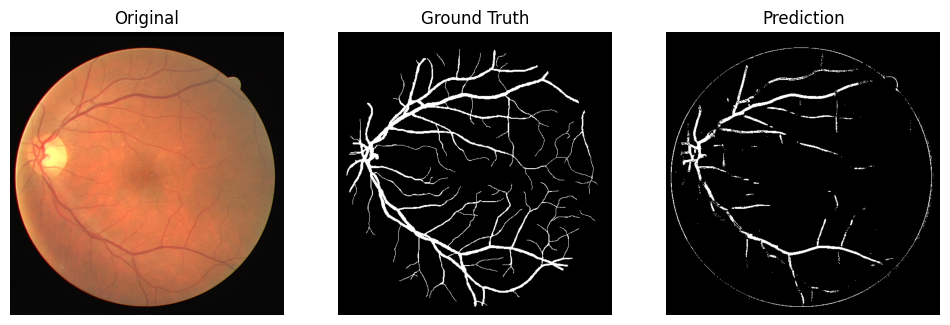

In [31]:
pred = predict_image(train_imgs[0], model)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(train_imgs[0], cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(train_gt[0], cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred, cmap='gray')
plt.axis("off")

plt.show()

In [32]:
def post_process(pred):
    pred = pred.astype(np.uint8) * 255

    # 1. remove small noise
    kernel = np.ones((3,3), np.uint8)
    opened = cv2.morphologyEx(pred, cv2.MORPH_OPEN, kernel)

    # 2. connect broken vessels
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

    return closed

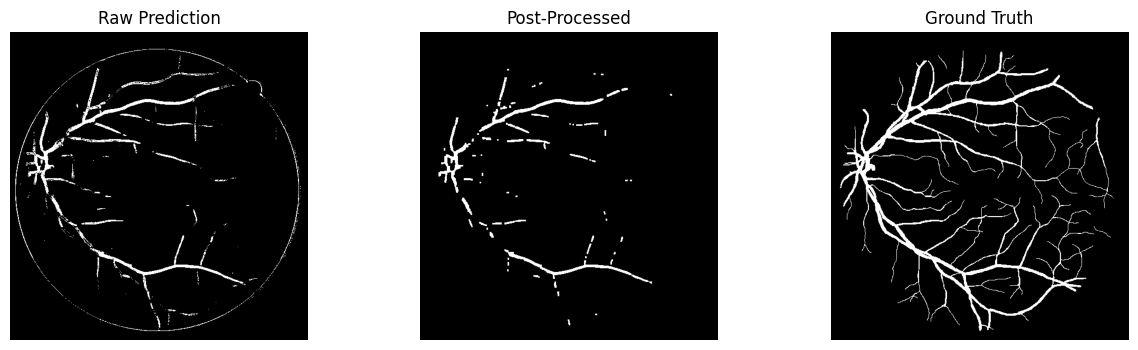

In [33]:
clean_pred = post_process(pred)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Raw Prediction")
plt.imshow(pred, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Post-Processed")
plt.imshow(clean_pred, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Ground Truth")
plt.imshow(train_gt[0], cmap='gray')
plt.axis("off")

plt.show()

In [34]:
def post_process(pred):
    pred = pred.astype(np.uint8) * 255

    kernel = np.ones((3,3), np.uint8)

    # 1. connect broken vessels
    closed = cv2.morphologyEx(pred, cv2.MORPH_CLOSE, kernel)

    # 2. slight dilation (makes vessels stronger)
    dilated = cv2.dilate(closed, kernel, iterations=1)

    return dilated

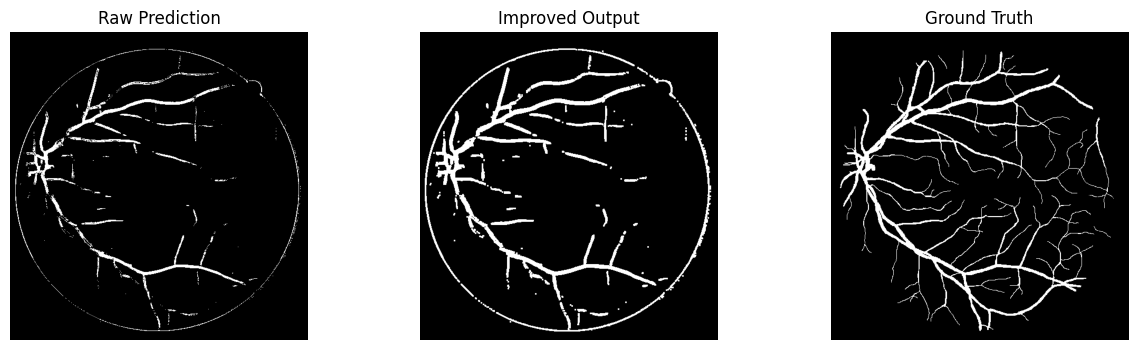

In [35]:
clean_pred = post_process(pred)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.title("Raw Prediction")
plt.imshow(pred, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Improved Output")
plt.imshow(clean_pred, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Ground Truth")
plt.imshow(train_gt[0], cmap='gray')
plt.axis("off")

plt.show()

In [42]:
test_imgs, test_gt, test_fov = load_drive_data(base_path, 'test')

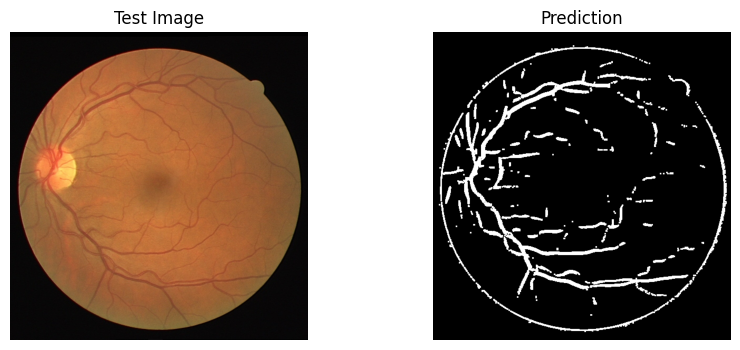

In [44]:
test_img = test_imgs[0]

pred_test = predict_image(test_img, model)
clean_test = post_process(pred_test)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Test Image")
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Prediction")
plt.imshow(clean_test, cmap='gray')
plt.axis("off")

plt.show()